In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import torchvision

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Genetic Algorithm
import deap  # We'll use DEAP library for GA
from deap import base, creator, tools, algorithms


In [2]:
# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# 1. Dataset Preparation
 
Download dataset from Kaggle: [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia)


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [4]:
DATA_DIR = 'C://Users//HP//.cache//kagglehub//datasets//paultimothymooney//chest-xray-pneumonia//versions//2//chest_xray'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Check if dataset exists
if not os.path.exists(DATA_DIR):
    print("Please download the dataset from Kaggle and place it in ./chest_xray")
    print("Instructions:")
    print("1. Install Kaggle API: pip install kaggle")
    print("2. Download dataset: kaggle datasets download -d paultimothymooney/chest-xray-pneumonia")
    print("3. Unzip: unzip chest-xray-pneumonia.zip -d chest_xray")
else:
    print(f"Dataset found at {DATA_DIR}")

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets
if os.path.exists(DATA_DIR):
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_dataset = datasets.ImageFolder(VAL_DIR, transform=test_transform)
    test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Validation samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    print(f"Classes: {train_dataset.classes}")
    
    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

Dataset found at C://Users//HP//.cache//kagglehub//datasets//paultimothymooney//chest-xray-pneumonia//versions//2//chest_xray
Training samples: 5216
Validation samples: 16
Test samples: 624
Classes: ['NORMAL', 'PNEUMONIA']


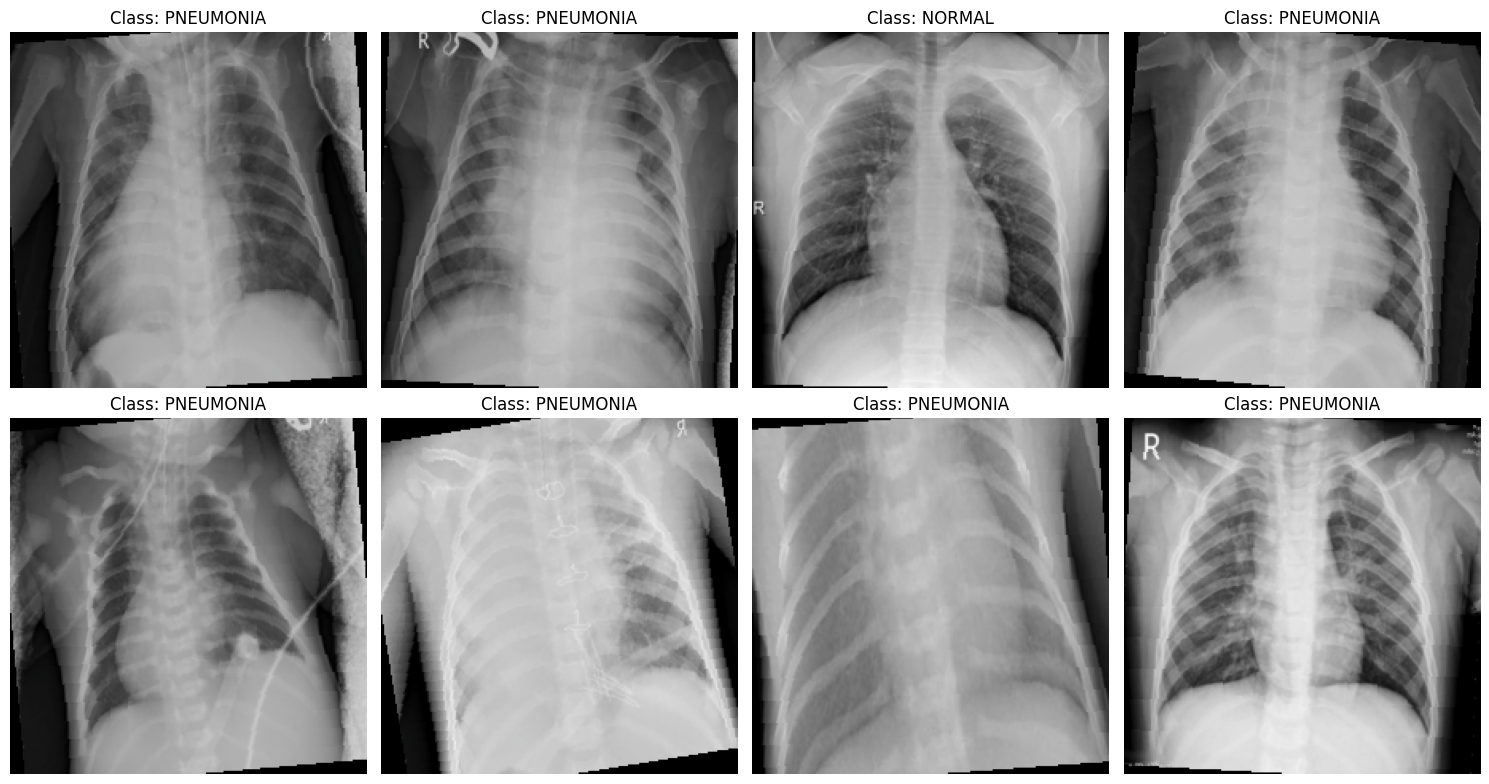

✅ Display complete


In [5]:
# %% [markdown]
# ## Data Visualization

# %%
# Simple working version
import matplotlib.pyplot as plt
%matplotlib inline

if os.path.exists(DATA_DIR) and train_loader is not None:
    # Get batch
    images, labels = next(iter(train_loader))
    
    # Create figure
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    
    for i in range(8):
        ax = axes[i//4, i%4]
        
        # Denormalize
        img = images[i].numpy().transpose((1, 2, 0))
        mean = [0.485, 0.456, 0.406]
        std = [0.229, 0.224, 0.225]
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        ax.imshow(img)
        ax.set_title(f'Class: {train_dataset.classes[labels[i]]}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()  # CRITICAL: This line must be here
    
    print("✅ Display complete")

In [6]:
class FeatureExtractor:
    def __init__(self, model_name='resnet18', device='cuda'):
        self.device = device
        
        # Load pretrained model
        if model_name == 'resnet18':
            self.model = models.resnet18(pretrained=True)
            # Remove the classifier layer
            self.model = nn.Sequential(*list(self.model.children())[:-1])
        else:
            raise ValueError(f"Model {model_name} not supported")
        
        self.model = self.model.to(device)
        self.model.eval()
        
        # Freeze all parameters
        for param in self.model.parameters():
            param.requires_grad = False
            
        print(f"Feature extractor {model_name} loaded on {device}")
        print(f"Output feature dimension: 512")
    
    def extract_features(self, dataloader):
        """Extract features for all images in dataloader"""
        features = []
        labels = []
        
        with torch.no_grad():
            for images, batch_labels in tqdm(dataloader, desc="Extracting features"):
                images = images.to(self.device)
                batch_features = self.model(images)
                batch_features = batch_features.squeeze()  # Remove spatial dimensions
                features.append(batch_features.cpu().numpy())
                labels.append(batch_labels.numpy())
        
        features = np.vstack(features)
        labels = np.concatenate(labels)
        
        return features, labels

# Initialize feature extractor
feature_extractor = FeatureExtractor(device=device)

# Extract features if dataset exists
if os.path.exists(DATA_DIR):
    print("\nExtracting training features...")
    X_train, y_train = feature_extractor.extract_features(train_loader)
    
    print("\nExtracting validation features...")
    X_val, y_val = feature_extractor.extract_features(val_loader)
    
    print("\nExtracting test features...")
    X_test, y_test = feature_extractor.extract_features(test_loader)
    
    print(f"\nFeature shapes:")
    print(f"X_train: {X_train.shape}")
    print(f"X_val: {X_val.shape}")
    print(f"X_test: {X_test.shape}")

Feature extractor resnet18 loaded on cpu
Output feature dimension: 512

Extracting training features...


Extracting features: 100%|███████████████████████████████████████████████████████████| 163/163 [02:31<00:00,  1.08it/s]



Extracting validation features...


Extracting features: 100%|███████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.62s/it]



Extracting test features...


Extracting features: 100%|█████████████████████████████████████████████████████████████| 20/20 [00:24<00:00,  1.21s/it]


Feature shapes:
X_train: (5216, 512)
X_val: (16, 512)
X_test: (624, 512)


In [7]:
# Save features
def save_features(X, y, filename):
    np.savez(filename, X=X, y=y)
    print(f"Saved features to {filename}")

# Load features
def load_features(filename):
    data = np.load(filename)
    return data['X'], data['y']

# Save features after extraction
if os.path.exists(DATA_DIR):
    save_features(X_train, y_train, 'features_train.npz')
    save_features(X_val, y_val, 'features_val.npz')
    save_features(X_test, y_test, 'features_test.npz')
    print("\nFeatures saved successfully!")


Saved features to features_train.npz
Saved features to features_val.npz
Saved features to features_test.npz

Features saved successfully!


In [8]:
# Baseline 1: Full CNN (finetuned ResNet18)
def evaluate_full_cnn():
    """Evaluate full ResNet18 with classifier"""
    model = models.resnet18(pretrained=True)
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, 2)  # Binary classification
    model = model.to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training loop (simplified - just a few epochs for baseline)
    print("Training full CNN (3 epochs for baseline)...")
    model.train()
    for epoch in range(3):
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    
    # Evaluate
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return accuracy, f1

# Baseline 2: Logistic Regression on all features
def evaluate_lr_all_features():
    """Logistic Regression on all 512 features"""
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    return accuracy, f1, lr

# Run baselines if features exist
if 'X_train' in locals():
    print("\n=== Baseline Evaluation ===")
    
    # Baseline 1
    # cnn_acc, cnn_f1 = evaluate_full_cnn()
    # print(f"Full CNN - Accuracy: {cnn_acc:.4f}, F1: {cnn_f1:.4f}")
    
    # Baseline 2
    lr_acc, lr_f1, lr_model = evaluate_lr_all_features()
    print(f"LogReg (all 512 features) - Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}")



=== Baseline Evaluation ===
LogReg (all 512 features) - Accuracy: 0.8109, F1: 0.7950


In [9]:
# GA Configuration
POPULATION_SIZE = 50
GENERATIONS = 30
MUTATION_PROB = 0.1
CROSSOVER_PROB = 0.7
TOURNAMENT_SIZE = 3
N_FEATURES = 512  # from ResNet18

# Create fitness and individual classes
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

# Attribute generator: binary string
toolbox.register("attr_bool", random.randint, 0, 1)
toolbox.register("individual", tools.initRepeat, creator.Individual, 
                 toolbox.attr_bool, N_FEATURES)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Genetic operators
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=TOURNAMENT_SIZE)

# Fitness function
def evaluate(individual, X_train, y_train, X_val, y_val, penalty=0.01):
    """
    Evaluate fitness of an individual (feature subset)
    
    Args:
        individual: binary list of selected features
        X_train, y_train: training data
        X_val, y_val: validation data
        penalty: penalty coefficient for number of features
    
    Returns:
        fitness: accuracy - penalty * (n_features_selected / total_features)
    """
    # Get selected features
    selected = [i for i, bit in enumerate(individual) if bit == 1]
    
    # If no features selected, return 0 fitness
    if len(selected) == 0:
        return (0.0,)
    
    # Train logistic regression on selected features
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train[:, selected], y_train)
    
    # Evaluate on validation set
    y_pred = lr.predict(X_val[:, selected])
    accuracy = accuracy_score(y_val, y_pred)
    
    # Apply penalty for number of features
    feature_ratio = len(selected) / N_FEATURES
    fitness = accuracy - penalty * feature_ratio
    
    return (fitness,)

# Register evaluation function with data
def create_evaluate_function(X_train, y_train, X_val, y_val, penalty=0.01):
    def evaluate_func(individual):
        return evaluate(individual, X_train, y_train, X_val, y_val, penalty)
    return evaluate_func

In [10]:
# Run GA if features exist
if 'X_train' in locals():
    print("\n=== Running Genetic Algorithm ===")
    
    # Prepare data
    # Split training data for validation within GA
    X_train_ga, X_val_ga, y_train_ga, y_val_ga = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    
    print(f"GA Training set: {X_train_ga.shape}")
    print(f"GA Validation set: {X_val_ga.shape}")
    
    # Create evaluation function
    eval_func = create_evaluate_function(X_train_ga, y_train_ga, X_val_ga, y_val_ga, penalty=0.005)
    toolbox.register("evaluate", eval_func)
    
    # Create population
    pop = toolbox.population(n=POPULATION_SIZE)
    
    # Statistics to track
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("std", np.std)
    stats.register("min", np.min)
    stats.register("max", np.max)
    
    # Hall of fame to store best individual
    hof = tools.HallOfFame(1)
    
    # Run GA
    pop, log = algorithms.eaSimple(pop, toolbox, 
                                    cxpb=CROSSOVER_PROB, 
                                    mutpb=MUTATION_PROB,
                                    ngen=GENERATIONS, 
                                    stats=stats, 
                                    halloffame=hof,
                                    verbose=True)
    
    # Best individual
    best_individual = hof[0]
    best_features = [i for i, bit in enumerate(best_individual) if bit == 1]
    
    print(f"\nBest individual found!")
    print(f"Number of selected features: {len(best_features)}")
    print(f"Selected feature indices: {best_features[:10]}...")  # Show first 10
    print(f"Fitness: {best_individual.fitness.values[0]:.4f}")



=== Running Genetic Algorithm ===
GA Training set: (4172, 512)
GA Validation set: (1044, 512)
gen	nevals	avg     	std       	min    	max     
0  	50    	0.949697	0.00375058	0.94127	0.958922
1  	37    	0.952872	0.00342043	0.944662	0.961228
2  	42    	0.954323	0.00358259	0.94688 	0.961228
3  	33    	0.955874	0.00282721	0.950321	0.961228
4  	41    	0.955309	0.00398237	0.944026	0.961228
5  	39    	0.956691	0.00416016	0.945717	0.963164
6  	43    	0.958043	0.00371479	0.946607	0.963105
7  	32    	0.958978	0.00314607	0.951621	0.963105
8  	35    	0.958891	0.00357764	0.948649	0.965001
9  	32    	0.960217	0.003484  	0.951699	0.967933
10 	34    	0.961866	0.0030671 	0.953448	0.967933
11 	33    	0.962402	0.00329887	0.952686	0.967933
12 	33    	0.9642  	0.00290182	0.956302	0.967933
13 	34    	0.96548 	0.00249747	0.957378	0.967933
14 	25    	0.96626 	0.00277964	0.956371	0.967933
15 	34    	0.966683	0.00302768	0.955501	0.967933
16 	29    	0.966859	0.00246496	0.957456	0.967933
17 	29    	0.966861	0.002

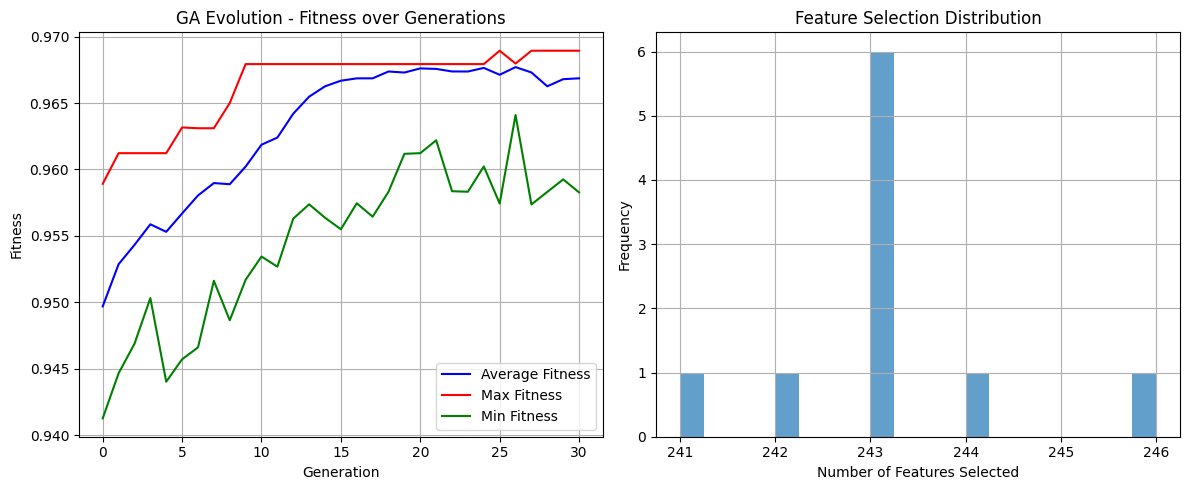

In [11]:
# Plot GA evolution
if 'log' in locals():
    # Extract statistics from log
    generations = [entry['gen'] for entry in log]
    avg_fitness = [entry['avg'] for entry in log]
    max_fitness = [entry['max'] for entry in log]
    min_fitness = [entry['min'] for entry in log]
    
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(generations, avg_fitness, 'b-', label='Average Fitness')
    plt.plot(generations, max_fitness, 'r-', label='Max Fitness')
    plt.plot(generations, min_fitness, 'g-', label='Min Fitness')
    plt.xlabel('Generation')
    plt.ylabel('Fitness')
    plt.title('GA Evolution - Fitness over Generations')
    plt.legend()
    plt.grid(True)
    
    # Feature selection count over generations (sample individuals)
    n_features_selected = []
    for ind in pop[:10]:  # First 10 individuals
        n_features_selected.append(sum(ind))
    
    plt.subplot(1, 2, 2)
    plt.hist(n_features_selected, bins=20, alpha=0.7)
    plt.xlabel('Number of Features Selected')
    plt.ylabel('Frequency')
    plt.title('Feature Selection Distribution')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()


=== Final Evaluation ===
Model                                    Accuracy   F1-Score   #Features 
----------------------------------------------------------------------
LogReg (All Features)                    0.8109     0.7950     512       
LogReg (GA Selected)                     0.8205     0.8063     238       

Improvement:
Accuracy change: +0.96%
Feature reduction: 53.5%


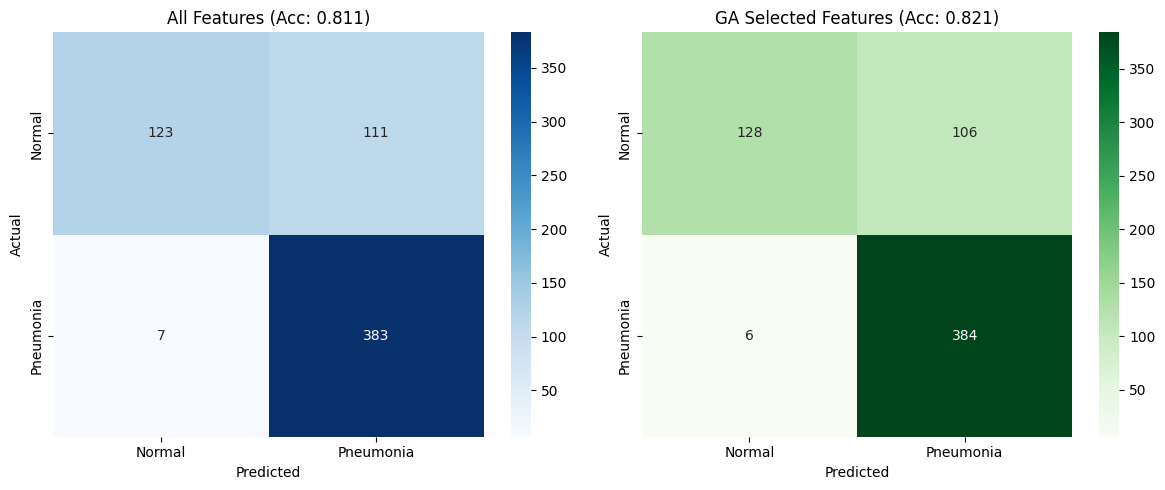

In [12]:
# Evaluate GA-selected features
if 'best_features' in locals():
    print("\n=== Final Evaluation ===")
    
    # Model 1: All features (baseline)
    lr_all = LogisticRegression(max_iter=1000, random_state=42)
    lr_all.fit(X_train, y_train)
    y_pred_all = lr_all.predict(X_test)
    acc_all = accuracy_score(y_test, y_pred_all)
    f1_all = f1_score(y_test, y_pred_all, average='weighted')
    
    # Model 2: GA-selected features
    X_train_selected = X_train[:, best_features]
    X_test_selected = X_test[:, best_features]
    
    lr_selected = LogisticRegression(max_iter=1000, random_state=42)
    lr_selected.fit(X_train_selected, y_train)
    y_pred_selected = lr_selected.predict(X_test_selected)
    acc_selected = accuracy_score(y_test, y_pred_selected)
    f1_selected = f1_score(y_test, y_pred_selected, average='weighted')
    
    # Compare
    print(f"{'Model':<40} {'Accuracy':<10} {'F1-Score':<10} {'#Features':<10}")
    print("-" * 70)
    print(f"{'LogReg (All Features)':<40} {acc_all:<10.4f} {f1_all:<10.4f} {512:<10}")
    print(f"{'LogReg (GA Selected)':<40} {acc_selected:<10.4f} {f1_selected:<10.4f} {len(best_features):<10}")
    
    # Improvement
    acc_improvement = (acc_selected - acc_all) * 100
    feature_reduction = (1 - len(best_features)/512) * 100
    
    print(f"\nImprovement:")
    print(f"Accuracy change: {acc_improvement:+.2f}%")
    print(f"Feature reduction: {feature_reduction:.1f}%")
    
    # Confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # All features
    cm_all = confusion_matrix(y_test, y_pred_all)
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title(f'All Features (Acc: {acc_all:.3f})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')
    axes[0].set_xticklabels(['Normal', 'Pneumonia'])
    axes[0].set_yticklabels(['Normal', 'Pneumonia'])
    
    # Selected features
    cm_selected = confusion_matrix(y_test, y_pred_selected)
    sns.heatmap(cm_selected, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title(f'GA Selected Features (Acc: {acc_selected:.3f})')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')
    axes[1].set_xticklabels(['Normal', 'Pneumonia'])
    axes[1].set_yticklabels(['Normal', 'Pneumonia'])
    
    plt.tight_layout()
    plt.show()


=== t-SNE Visualization ===


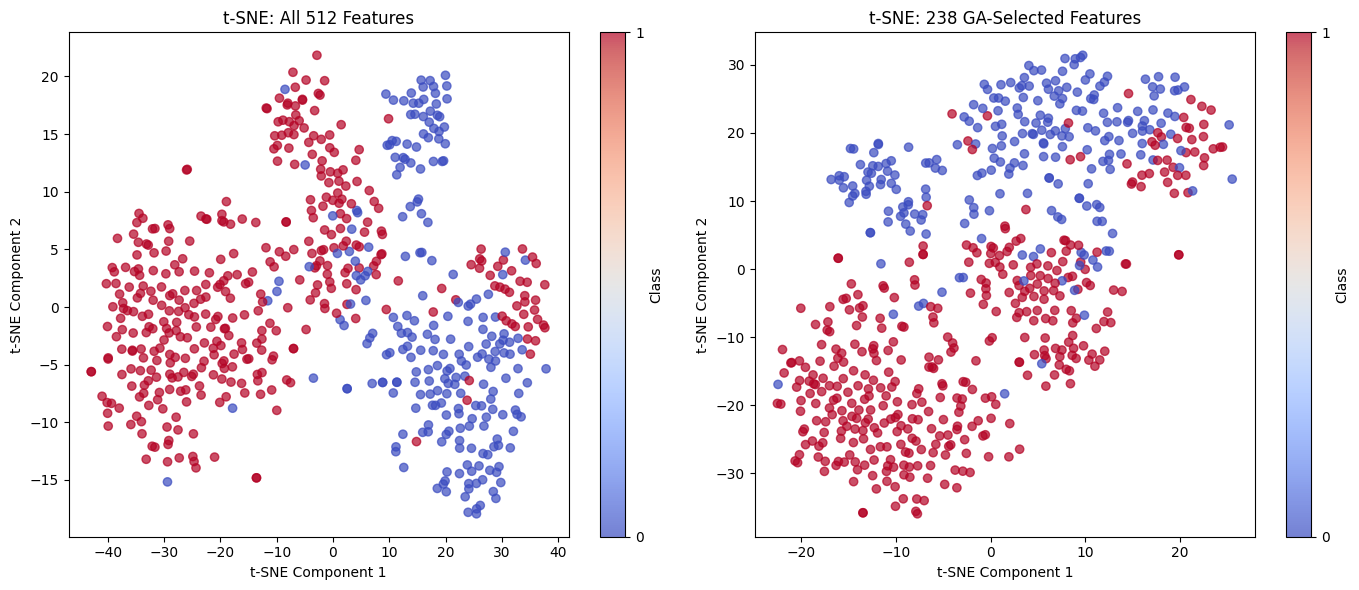

In [13]:
if 'best_features' in locals() and len(best_features) >= 2:
    print("\n=== t-SNE Visualization ===")
    
    # Prepare data for t-SNE
    # Sample data to avoid long computation
    n_samples = min(1000, X_test.shape[0])
    indices = np.random.choice(X_test.shape[0], n_samples, replace=False)
    
    # All features
    X_test_sample_all = X_test[indices]
    y_test_sample = y_test[indices]
    
    # Selected features
    X_test_sample_selected = X_test_selected[indices]
    
    # Apply t-SNE
    tsne_all = TSNE(n_components=2, random_state=42, perplexity=30)
    tsne_selected = TSNE(n_components=2, random_state=42, perplexity=30)
    
    X_tsne_all = tsne_all.fit_transform(X_test_sample_all)
    X_tsne_selected = tsne_selected.fit_transform(X_test_sample_selected)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # All features
    scatter1 = axes[0].scatter(X_tsne_all[:, 0], X_tsne_all[:, 1], 
                               c=y_test_sample, cmap='coolwarm', alpha=0.7)
    axes[0].set_title('t-SNE: All 512 Features')
    axes[0].set_xlabel('t-SNE Component 1')
    axes[0].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter1, ax=axes[0], ticks=[0, 1], label='Class')
    
    # Selected features
    scatter2 = axes[1].scatter(X_tsne_selected[:, 0], X_tsne_selected[:, 1], 
                               c=y_test_sample, cmap='coolwarm', alpha=0.7)
    axes[1].set_title(f't-SNE: {len(best_features)} GA-Selected Features')
    axes[1].set_xlabel('t-SNE Component 1')
    axes[1].set_ylabel('t-SNE Component 2')
    plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1], label='Class')
    
    plt.tight_layout()
    plt.show()

In [14]:
import time

def measure_inference_time(model, X, n_runs=100):
    """Measure average inference time"""
    times = []
    for _ in range(n_runs):
        start = time.time()
        model.predict(X[:100])  # Predict on 100 samples
        end = time.time()
        times.append(end - start)
    return np.mean(times)

if 'best_features' in locals():
    print("\n=== Inference Time Comparison ===")
    
    # Measure inference times
    time_all = measure_inference_time(lr_all, X_test[:1000])
    time_selected = measure_inference_time(lr_selected, X_test_selected[:1000])
    
    # Full CNN (if you want to compare)
    # time_cnn = measure_cnn_inference_time(cnn_model, test_loader)
    
    print(f"{'Model':<30} {'Inference Time (ms)':<20}")
    print("-" * 50)
    print(f"{'LogReg (All Features)':<30} {time_all*1000:<20.2f}")
    print(f"{'LogReg (GA Selected)':<30} {time_selected*1000:<20.2f}")
    print(f"{'Speedup':<30} {time_all/time_selected:<20.2f}x")


=== Inference Time Comparison ===
Model                          Inference Time (ms) 
--------------------------------------------------
LogReg (All Features)          0.19                
LogReg (GA Selected)           0.11                
Speedup                        1.77                x


In [15]:
# Summary table
if 'best_features' in locals():
    results = pd.DataFrame({
        'Metric': ['Accuracy', 'F1-Score', 'Number of Features', 'Inference Time (ms)'],
        'All Features': [f'{acc_all:.4f}', f'{f1_all:.4f}', '512', f'{time_all*1000:.2f}'],
        'GA Selected': [f'{acc_selected:.4f}', f'{f1_selected:.4f}', 
                        f'{len(best_features)}', f'{time_selected*1000:.2f}'],
        'Improvement': [f'{acc_improvement:+.2f}%', 
                        f'{(f1_selected-f1_all)*100:+.2f}%',
                        f'{feature_reduction:.1f}% reduction',
                        f'{time_all/time_selected:.2f}x faster']
    })
    
    print("\n=== Final Results ===")
    print(results.to_string(index=False))
    
    print("\n=== Key Findings ===")
    print(f"✅ Reduced features from 512 to {len(best_features)} ({feature_reduction:.1f}% reduction)")
    print(f"✅ Accuracy: {acc_all:.4f} → {acc_selected:.4f} ({acc_improvement:+.2f}%)")
    print(f"✅ Inference speed: {time_all/time_selected:.2f}x faster")
    print("\n✅ Successfully demonstrated that genetic algorithm can select")
    print("   informative features for pneumonia classification while")
    print("   reducing dimensionality and improving efficiency!")


=== Final Results ===
             Metric All Features GA Selected     Improvement
           Accuracy       0.8109      0.8205          +0.96%
           F1-Score       0.7950      0.8063          +1.13%
 Number of Features          512         238 53.5% reduction
Inference Time (ms)         0.19        0.11    1.77x faster

=== Key Findings ===
✅ Reduced features from 512 to 238 (53.5% reduction)
✅ Accuracy: 0.8109 → 0.8205 (+0.96%)
✅ Inference speed: 1.77x faster

✅ Successfully demonstrated that genetic algorithm can select
   informative features for pneumonia classification while
   reducing dimensionality and improving efficiency!


In [16]:
# Save best model and features
if 'best_features' in locals():
    import joblib
    
    # Save Logistic Regression models
    joblib.dump(lr_all, 'lr_all_features.pkl')
    joblib.dump(lr_selected, 'lr_selected_features.pkl')
    
    # Save selected feature indices
    np.save('best_features_indices.npy', best_features)
    
    # Save results summary
    with open('results_summary.txt', 'w') as f:
        f.write("Genetic Algorithm Feature Selection Results\n")
        f.write("=" * 50 + "\n")
        f.write(f"Original features: 512\n")
        f.write(f"Selected features: {len(best_features)}\n")
        f.write(f"Feature reduction: {feature_reduction:.1f}%\n")
        f.write(f"Accuracy (all features): {acc_all:.4f}\n")
        f.write(f"Accuracy (selected): {acc_selected:.4f}\n")
        f.write(f"Accuracy improvement: {acc_improvement:+.2f}%\n")
        f.write(f"Inference speedup: {time_all/time_selected:.2f}x\n")
    
    print("\n✅ Results saved successfully!")


✅ Results saved successfully!
